# Toy 1D manifold

Loads the score net trained in `01_train_score.ipynb` and runs FR-guided sampling through (`driver.guided_reverse_loop`). 

Compares:
- **guidance method**: k-NN Fisher-Rao energy (`basic_fr.py`) vs. score-divergence energy (`score_divergence.py`) (algo 2 in the manuscript).
- **jacobian**: none (full ambient R^2) vs. projected onto a rank-1 tangent (`JACOBIAN_TYPE` selects `"closed-form"`, the ground-truth tangent of `y = 0.6 sin(2x)`, or `"auto-diff"`, the exact jacrev-computed tangent).
- **guidance time-window**: varying the guidance penalty window.
- **penalty strength** `lam`: swept over several values.
- **gradient clipping**: swept over several fixed norms, plus one adaptive option -- `grad_clip="adaptive_score_norm"`
  (`ADAPTIVE_CLIP`) caps the guidance gradient's norm at `||score(z_t, t)||` itself (computed by `score_norm_clip_fn`),
  i.e. the cap moves with `x` and `t` instead of being one hand-picked constant for the whole trajectory. Support for
  this lives in `driver.py`: `grad_clip` there can now be `None`, a fixed scalar, or any callable `f(z_t) -> per-row
  cap`. Anecdotally this adaptive cap has looked like the best-performing option so far -- it's now folded into the
  sweep below (`config["grad_clips"]`) instead of only being tried by hand.

**Metrics** (per user spec):
- **Memorization**: per-sample ratio `dist_to_nearest_atom / dist_to_second_nearest_atom`; a sample counts as memorized if this ratio is belor a threshold.
-  `mem_ratio` = fraction of samples memorized.
- **Fidelity**: mean squared distance to the manifold (`fidelity_mse`).

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr, score_divergence, bayesian_fr

REGIME = "normal"   # "normal" or "overtrained" - selects checkpoints/score_{REGIME}_N{N}.pt
N = int(os.environ.get("N_DATA", 30)) #other saved N options - 10, 20, 30, 50, 100
JACOBIAN_TYPE = os.environ.get("JACOBIAN_TYPE", "closed-form")   # "closed-form" (hand-written analytic
                                                                    # tangent) or "auto-diff" (exact
                                                                    # jacrev-computed tangent) -- selects
                                                                    # what the "projected" jacobian uses,
                                                                    # see JACOBIANS below
TAG = f"{REGIME}_N{N}"
ckpt = torch.load(f"checkpoints/score_{TAG}.pt", weights_only=False)
train_config = ckpt["config"]
d, device = train_config["d"], train_config["device"]
X_target = ckpt["X_target"].to(device)
u_target = ckpt["u_target"].to(device)

# All of THIS notebook's own outputs (figs, csv) go here, one folder per (N, REGIME) combo -- change
# either above and a fresh folder is created automatically, instead of everything piling up flat in
# checkpoints/ distinguished only by a filename suffix. The score/jacnet checkpoint LOAD path above is
# unaffected (that's 01_train_score.ipynb's output, not this notebook's).
OUT_DIR = f"checkpoints/N{N}-{REGIME}"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"regime={REGIME}  N={N}  d={d}, device={device}, N_data={X_target.shape[0]}, iters={train_config['iters']}")
print(f"outputs -> {OUT_DIR}/")

regime=normal  N=30  d=2, device=cpu, N_data=30, iters=50000
outputs -> checkpoints/N30-normal/


In [2]:
class ScoreNet(nn.Module):
    def __init__(self, d, hidden, depth):
        super().__init__()
        self.input_proj = nn.Linear(d + 1, hidden)
        self.layers = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(depth * 2)])
        self.output_proj = nn.Linear(hidden, d)

    def forward(self, x, t):
        h = F.silu(self.input_proj(torch.cat([x, t[:, None]], dim=-1)))
        for i in range(0, len(self.layers), 2):
            r = F.silu(self.layers[i](h))
            r = self.layers[i + 1](r)
            h = h + r
        return self.output_proj(h)

net = ScoreNet(d, train_config["hidden"], train_config["depth"]).to(device)
net.load_state_dict(ckpt["net_state"])
net.eval()
print("Loaded score net.")

Loaded score net.


In [3]:
ADAPTIVE_CLIP = "adaptive_score_norm"   # sentinel for config["grad_clips"]: cap the guidance grad's
                                         # norm at ||score(z_t, t)|| instead of a fixed constant --
                                         # see score_norm_clip_fn below.

config = {
    "beta_min": train_config["beta_min"], "beta_max": train_config["beta_max"], "T": train_config["T"],
    "n_steps": 1000,
    "n_samples": 200,
    "seed": 10,
    "k_neighbors": 10,
    "r_probes": 5,
    "ell": 1,
    "mem_ratio_threshold": 1 / 5,
    "lambdas": [0.1],
    "grad_clips": [100, ADAPTIVE_CLIP],

    # Decouples basic_fr/bayesian_fr's softmax TEMPERATURE from their outer 1/sigma_t^2 SCALE (see
    # basic_fr.fisher_rao_energy's docstring). Without this, the posterior saturates to an exact
    # one-hot late in sampling (verified in float64, not a precision artifact), zeroing Var_q(g) --
    # and its gradient -- across 45-90%+ of the ambient grid as sigma_t -> 0. 0.05 is comfortably
    # below the typical squared inter-atom spacing on this curve.
    "beta_floor": 0.01,
    "beta_floors": [0.01],  # swept for basic_fr/bayesian_fr (score_divergence ignores it)
    "bb_B": 256,                    # Dirichlet bootstrap draws (bayesian_fr)
    "bb_alpha": 1.0,                # fallback/default Dirichlet concentration
    "bb_alphas": [0.1],  # swept as a hyperparameter, bayesian_fr only -- low alpha means
                                     # noisy bootstrap weights concentrated on few atoms, high alpha
                                     # pushes q_bar toward basic_fr's plain uniform-prior posterior
                                     # (q_bar -> q as alpha -> infinity)
}


windows = {
    "throughout": (0.0, 1),
   # "early": (0.0, 0.25),
    #"early_mid": (0.0, 0.5),
    "mid": (0.5, 0.85),
    "mid_late": (0.5, 1),
    "late": (0.75, 1),
    #"very_late": (0.85, 0.95),
    #"very_early": (0, 0.15)
}

# Schedule (VP-linear here; swap these four to change schedule -- everything else reads
# only beta/alpha_bar/sigma2/g2, never beta_min/beta_max directly).
def beta(t):
    return config["beta_min"] + t * (config["beta_max"] - config["beta_min"])

def alpha_bar(t):
    return torch.exp(-(config["beta_min"] * t + 0.5 * (config["beta_max"] - config["beta_min"]) * t ** 2))

def sigma2(t):
    return (1 - alpha_bar(t)).clamp(min=1e-4)

def g2(t):
    return beta(t)   # forward SDE's diffusion coefficient squared -- what step_scale_fn needs

## Wire up the generic interface for sampling and guidance

`base_step_fn(z_t, step_idx) -> z_{t-1}` is the plain reverse SDE step; `y_fn(z_t) -> y` is the denoiser
$D_t(z_t) = (z_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$.

In [4]:
n_steps = config["n_steps"]
dt = config["T"] / n_steps
t_vec_holder = {"t": None}

def make_base_step_fn():
    def base_step_fn(z_t, step_idx):
        k = n_steps - step_idx
        t_vec = torch.full((z_t.shape[0],), (k + 1) * dt, device=device)
        t_vec_holder["t"] = t_vec
        with torch.no_grad():
            eps_hat = net(z_t, t_vec)
            score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
            drift = -0.5 * beta(t_vec)[:, None] * z_t - beta(t_vec)[:, None] * score
            noise = beta(t_vec)[:, None].sqrt() * torch.randn_like(z_t) if k > 0 else 0
        return z_t - drift * dt + noise * dt ** 0.5
    return base_step_fn

def y_fn(z_t):
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    a = alpha_bar(t_vec)
    return (z_t - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt()

def score_norm_clip_fn(z_t):
    # Adaptive grad_clip: caps the guidance gradient's norm at ||score(z_t, t)|| itself, evaluated at
    # the same z_t/t the guidance step is being taken at, rather than one fixed constant for every x
    # and every t. driver.guidance_grad/projected_guidance_grad call this with the current z_t via
    # _resolve_clip_norm whenever grad_clip is a callable (see driver.py) -- t_vec_holder["t"] is
    # already set by whichever step is currently running (base_step_fn, or the caller explicitly, as
    # guided_score below does), same pattern as y_fn/score_fn.
    t_vec = t_vec_holder["t"]
    eps_hat = net(z_t, t_vec)
    score = -eps_hat / sigma2(t_vec)[:, None].sqrt()
    return score.norm(dim=-1, keepdim=True)

def step_scale_fn(step_idx):
    # guidance must scale like g(t)^2 * dt (form the reverse-SDE derivation)
    k = n_steps - step_idx
    t_vec = torch.full((config["n_samples"],), (k + 1) * dt, device=device)
    return g2(t_vec)[:, None] * dt

## Guidance energies

**k-NN Fisher-Rao** (`basic_fr.fisher_rao_energy`, the "Basic" algorithm variant): `beta_t` is pinned to `sigma_t^2` (the schedule's own noise variance), *not* a free hyperparameter -- unlike the old `preliminary/fisher_rao_guidance_so(n).ipynb` notebook's `config["beta_fr"]`, which had to be hand-tuned and is exactly the "how do we choose temperature" pain point. This module sidesteps that by construction.

**Score-divergence** (`score_divergence.make_score_div_energy_fn`): `I(y) = trace(grad_y s_theta(y,t)) + d/sigma_t^2`, estimated with `r_probes` Hutchinson probes -- no atom index, no temperature parameter of any kind.

**Bayesian FR** (`bayesian_fr.fisher_rao_energy_bb`): same k retrieved atoms and same `beta_t = sigma_t^2` as `basic_fr`, but the softmax posterior `q` over those k atoms is replaced by `q_bar` -- `bb_B` draws of a `Dirichlet(bb_alpha)` prior over the k atoms, each combined with the data term into a Gibbs posterior, then averaged. `q_bar -> q` (basic_fr's uniform-prior posterior) only as `bb_alpha -> infinity`; `bb_alpha=1.0` is the canonical flat-Dirichlet bootstrap. No new temperature knob -- only the prior over atoms changes.

In [5]:
index = basic_fr.build_flat_index(X_target)

def make_knn_energy_fn(beta_floor=None):
    def energy_fn(y):
        with torch.no_grad():
            neighbors, _ = basic_fr.ann_query(index, y, config["k_neighbors"])
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2(t_vec_holder["t"]),
                                              beta_floor=beta_floor if beta_floor is not None else config["beta_floor"])
        return I
    return energy_fn

def score_fn(y):
    t_vec = t_vec_holder["t"]
    eps_hat = net(y, t_vec)
    return -eps_hat / sigma2(t_vec)[:, None].sqrt()

def sigma2_fn():
    return sigma2(t_vec_holder["t"])

def d_fn():
    return d

def make_score_divergence_energy_fn():
    return score_divergence.make_score_div_energy_fn(score_fn, sigma2_fn, d_fn, r=config["r_probes"])

def make_bayesian_fr_energy_fn(alpha=None, beta_floor=None):
    return bayesian_fr.make_knn_bayesian_fr_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        B=config["bb_B"], dirichlet_alpha=alpha if alpha is not None else config["bb_alpha"],
        beta_floor=beta_floor if beta_floor is not None else config["beta_floor"])

ENERGY_FACTORIES = {
    "basic_fr": make_knn_energy_fn,
   "score_divergence": make_score_divergence_energy_fn,
   # "bayesian_fr": make_bayesian_fr_energy_fn,
}

# Tangent-projected counterparts: energy_fn(y, P) -> I, restricted to tangent directions by
# construction (see driver.projected_guidance_grad) rather than only reprojecting a downstream
# gradient. k=1 for score-divergence's flat-Gaussian correction term since the toy manifold's
# analytic tangent (below) is rank 1 by construction.
def make_knn_projected_energy_fn(beta_floor=None):
    return basic_fr.make_knn_projected_energy_fn(index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
                                                  beta_floor=beta_floor if beta_floor is not None else config["beta_floor"])

def make_score_divergence_projected_energy_fn():
    return score_divergence.make_score_div_projected_energy_fn(score_fn, sigma2_fn, k_fn=lambda: 1, r=config["r_probes"])

def make_bayesian_fr_projected_energy_fn(alpha=None, beta_floor=None):
    return bayesian_fr.make_knn_bayesian_projected_energy_fn(
        index, config["k_neighbors"], lambda: sigma2(t_vec_holder["t"]),
        B=config["bb_B"], dirichlet_alpha=alpha if alpha is not None else config["bb_alpha"],
        beta_floor=beta_floor if beta_floor is not None else config["beta_floor"])

PROJECTED_ENERGY_FACTORIES = {
    "basic_fr": make_knn_projected_energy_fn,
    "score_divergence": make_score_divergence_projected_energy_fn,
    "bayesian_fr": make_bayesian_fr_projected_energy_fn,
}

## Tangent Jacobian: closed-form vs. auto-diff (`JACOBIAN_TYPE`)

`JACOBIANS["projected"]` is a single rank-1 tangent projector (the manifold is 1-D in this R^2 ambient
space), but which Jacobian it's built from is a hyperparameter, `JACOBIAN_TYPE`, set above:

- **`"closed-form"`** (default): ground-truth tangent of `y = 0.6 sin(2x)`, written by hand -- exact but only
  possible because we happen to know the manifold's equation.
- **`"auto-diff"`**: no hand-written tangent at all. Forms the REAL per-sample Jacobian `M = d(score(y,t))/dy`
  via `torch.func.jacrev` + `vmap` (cheap here since `d=2`), symmetrizes it and rescales by `1/sigma_t^2` --
  exactly the quantity `experiments/so_n/02_train_jacnet.ipynb`'s JacNet is trained to *approximate* -- then
  eigendecomposes it with `driver.eig_tangent_projector(M, k=1, largest=False)` (via `driver.make_projector_fn`)
  to keep the single smallest-`|eigenvalue|` eigenvector as the estimated tangent direction. This is the exact
  Jacobian, not a learned surrogate.

Both builds `projector_fn(y) -> P`, feeding both the projected energy (`PROJECTED_ENERGY_FACTORIES`,
restricting `I` itself to tangent directions) and its gradient (`driver.projected_guidance_grad`, computed
directly in y-space then chained through `denoiser_jacobian_fn` into z_t-space).

Defined here (before the diagnostic below) so the diagnostic can plot projected gradient norms too.

In [6]:
def tangent_vec_from_u(u):
    t = torch.stack([torch.ones_like(u), 1.2 * torch.cos(2 * u)], dim=-1)
    return t / t.norm(dim=-1, keepdim=True)

def analytic_tangent_projector(y):
    u = y[:, 0].clamp(-3.2, 3.2)
    t = tangent_vec_from_u(u)          # [B, 2]
    return torch.einsum("bi,bj->bij", t, t)

# True autodiff Jacobian: no hand-written tangent, no learned JacNet -- the real per-sample
# d(score(y,t))/dy via torch.func.jacrev+vmap (cheap at d=2), symmetrized and rescaled by
# 1/sigma_t^2, exactly the quantity JacNet elsewhere is trained to approximate. Only built/used
# when JACOBIAN_TYPE == "auto-diff" (see below).
def score_at_single(y_i, t_i):
    eps_hat = net(y_i[None], t_i[None])
    return (-eps_hat / sigma2(t_i[None])[:, None].sqrt())[0]

_score_jacobian_fn = torch.func.vmap(torch.func.jacrev(score_at_single))

def autodiff_jacobian_matrix_fn(y):
    t_vec = t_vec_holder["t"]
    M_raw = _score_jacobian_fn(y, t_vec)
    M_tilde = 0.5 * (M_raw + M_raw.transpose(-1, -2))
    return (M_tilde / sigma2(t_vec)[:, None, None]).detach()

autodiff_tangent_projector = driver.make_projector_fn(autodiff_jacobian_matrix_fn, k=1, largest=False)

_PROJECTED_JACOBIANS = {"closed-form": analytic_tangent_projector, "auto-diff": autodiff_tangent_projector}
assert JACOBIAN_TYPE in _PROJECTED_JACOBIANS, f"JACOBIAN_TYPE must be one of {list(_PROJECTED_JACOBIANS)}"

JACOBIANS = {
    "unprojected": None,
    "projected": _PROJECTED_JACOBIANS[JACOBIAN_TYPE],
}

# The denoiser's own Jacobian dy/dz_t, exact via jacrev+vmap over y_fn itself (cheap at d=2): used
# to correctly map a y-space guidance gradient into z_t-space instead of assuming dy/dz_t =
# identity (driver.projected_guidance_grad's denoiser_jacobian_fn parameter). Without this,
# projected guidance's correction points in the WRONG direction (median cosine similarity to the
# true grad_z_t I(D_t(z_t), P) was negative) for 50-76% of samples during the noisiest ~20% of a
# reverse trajectory -- verified directly against this checkpoint.
def _y_fn_single(z_i, t_i):
    eps_hat = net(z_i[None], t_i[None])
    a = alpha_bar(t_i[None])
    return ((z_i[None] - (1 - a)[:, None].sqrt() * eps_hat) / a[:, None].sqrt())[0]

_denoiser_jacobian_fn_raw = torch.func.vmap(torch.func.jacrev(_y_fn_single))

def denoiser_jacobian_fn(z_t):
    t_vec = t_vec_holder["t"]
    return _denoiser_jacobian_fn_raw(z_t, t_vec).detach()

GRAD_CLIP_FNS = {ADAPTIVE_CLIP: score_norm_clip_fn}   # resolved to a callable at guidance-build time;
                                                       # every other grad_clip value passes through as
                                                       # the fixed scalar it already is (driver.py
                                                       # accepts both -- see _resolve_clip_norm).

def resolve_grad_clip(grad_clip):
    return GRAD_CLIP_FNS.get(grad_clip, grad_clip)

def fmt_clip(grad_clip):
    # grad_clip is either a fixed scalar (format as a number) or the ADAPTIVE_CLIP label (already a
    # readable string) -- used everywhere a grad_clip value gets printed/titled below.
    return grad_clip if isinstance(grad_clip, str) else f"{grad_clip:g}"

def make_guidance_fn(method, jacobian_name, grad_clip, bb_alpha=None, beta_floor=None):
    # bb_alpha only means anything for bayesian_fr (its Dirichlet concentration hyperparameter);
    # beta_floor means something for basic_fr and bayesian_fr (both use the k-NN softmax
    # temperature), but not score_divergence -- every method ignores whichever doesn't apply to
    # it, same signature either way so the sweep loop below can call make_guidance_fn uniformly.
    projector_fn = JACOBIANS[jacobian_name]
    if method == "bayesian_fr":
        energy_fn = (make_bayesian_fr_projected_energy_fn(bb_alpha, beta_floor) if projector_fn is not None
                     else make_bayesian_fr_energy_fn(bb_alpha, beta_floor))
    elif method == "basic_fr":
        energy_fn = (make_knn_projected_energy_fn(beta_floor) if projector_fn is not None
                     else make_knn_energy_fn(beta_floor))
    else:
        energy_fn = (PROJECTED_ENERGY_FACTORIES[method]() if projector_fn is not None
                     else ENERGY_FACTORIES[method]())
    grad_clip = resolve_grad_clip(grad_clip)
    if projector_fn is None:
        return driver.make_autograd_guidance_fn(y_fn, energy_fn, target_range=None, grad_clip=grad_clip)
    return driver.make_projected_guidance_fn(
        y_fn, energy_fn, projector_fn, target_range=None, grad_clip=grad_clip,
        denoiser_jacobian_fn=denoiser_jacobian_fn)

## Diagnostic: raw guidance gradient scale vs `t` (before clipping)


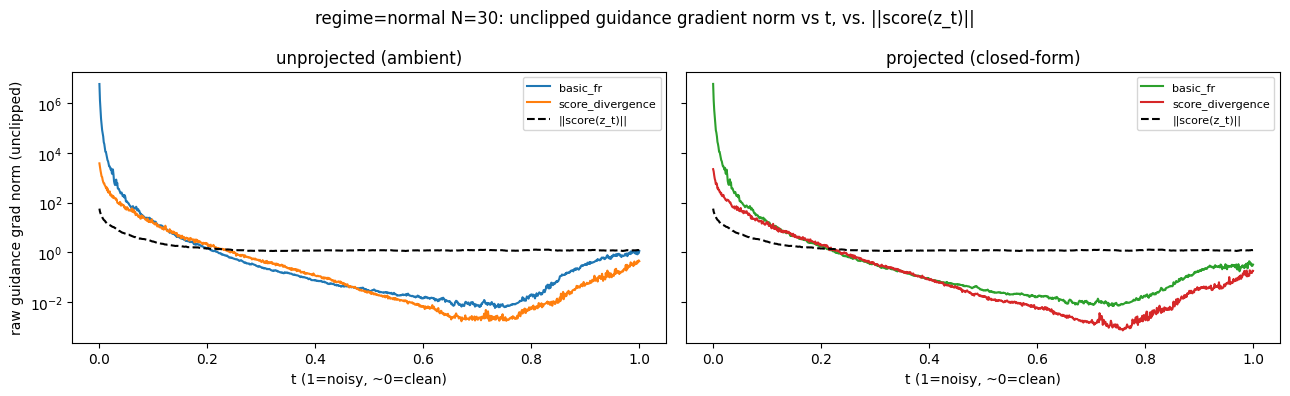

In [7]:
torch.manual_seed(config["seed"])
z = torch.randn(config["n_samples"], d, device=device)
base_step_fn = make_base_step_fn()
diag_energy_fns = {"basic_fr": make_knn_energy_fn(), "score_divergence": make_score_divergence_energy_fn()}
diag_projected_energy_fns = {"basic_fr": make_knn_projected_energy_fn(), "score_divergence": make_score_divergence_projected_energy_fn()}

diag_rows = []
score_norm_rows = []
for step_idx in range(1, n_steps + 1):
    z_next = base_step_fn(z, step_idx)   # also sets t_vec_holder["t"] for this step
    t_val = t_vec_holder["t"][0].item()
    sigma2_val = sigma2(t_vec_holder["t"])[0].item()
    with torch.no_grad():
        score = -net(z, t_vec_holder["t"]) / sigma2(t_vec_holder["t"])[:, None].sqrt()
    score_norm_rows.append({"step_idx": step_idx, "t": t_val, "score_norm_mean": score.norm(dim=-1).mean().item()})
    for name, energy_fn in diag_energy_fns.items():
        grad, _, _ = driver.guidance_grad(y_fn, z, energy_fn, target_range=None, grad_clip=None)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": False,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    for name, energy_fn in diag_projected_energy_fns.items():
        grad, _, _ = driver.projected_guidance_grad(y_fn, z, energy_fn, JACOBIANS["projected"], target_range=None, grad_clip=None,
                                                      denoiser_jacobian_fn=denoiser_jacobian_fn)
        gnorm = grad.norm(dim=-1)
        diag_rows.append({"step_idx": step_idx, "t": t_val, "sigma2": sigma2_val, "method": name, "projected": True,
                           "grad_norm_mean": gnorm.mean().item(), "grad_norm_max": gnorm.max().item()})
    z = z_next

diag_df = pd.DataFrame(diag_rows)
score_norm_df = pd.DataFrame(score_norm_rows)

UNPROJ_COLORS = {"basic_fr": "tab:blue", "score_divergence": "tab:orange"}
PROJ_COLORS = {"basic_fr": "tab:green", "score_divergence": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
for name, sub in diag_df[~diag_df["projected"]].groupby("method"):
    axes[0].plot(sub["t"], sub["grad_norm_mean"], label=name, color=UNPROJ_COLORS[name])
for name, sub in diag_df[diag_df["projected"]].groupby("method"):
    axes[1].plot(sub["t"], sub["grad_norm_mean"], label=name, color=PROJ_COLORS[name])

for ax, title in zip(axes, ["unprojected (ambient)", f"projected ({JACOBIAN_TYPE})"]):
    ax.plot(score_norm_df["t"], score_norm_df["score_norm_mean"], "--", color="black", label="||score(z_t)||")
    ax.set_xlabel("t (1=noisy, ~0=clean)"); ax.set_yscale("log"); ax.invert_xaxis()
    ax.set_title(title); ax.legend(fontsize=8)
axes[0].set_ylabel("raw guidance grad norm (unclipped)")
fig.suptitle(f"regime={REGIME} N={N}: unclipped guidance gradient norm vs t, vs. ||score(z_t)||")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/grad_norm_vs_t.png", dpi=120); plt.show()

## Metrics

- `mem_ratio`: fraction of samples with `dist(nearest atom) / dist(2nd-nearest atom) < mem_ratio_threshold`.
- `fidelity_mse`: mean squared distance to the true manifold curve (found by scanning the curve densely),
  computed **only over samples classified as NOT memorized**. A memorized sample already sits on (or
  essentially on) the manifold near a training atom, so folding it into the average would reward
  memorization instead of measuring whether guidance distorts the rest of the distribution -- `NaN` (not
  `0`) if every sample in a config is memorized, so that case doesn't get misread as "perfect fidelity"
  (pandas' `sort_values`/`idxmin` skip `NaN` by default, so such a config just won't win on this axis).

In [8]:
u_scan = torch.linspace(-4.0, 4.0, 4000, device=device)
curve_scan = torch.stack([u_scan, 0.6 * torch.sin(2 * u_scan)], dim=-1)   # [S, 2]

def dist_to_manifold(X):
    return torch.cdist(X, curve_scan).min(dim=1).values

def is_memorized(X, atoms, thresh):
    d2 = torch.cdist(X, atoms)
    top2 = torch.topk(d2, 2, largest=False, dim=1).values   # [B, 2], ascending
    ratio = top2[:, 0] / top2[:, 1].clamp(min=1e-8)
    return ratio.lt(thresh)

def evaluate(X):
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    unmem = ~mem
    fidelity = dist_to_manifold(X[unmem]).pow(2).mean().item() if unmem.any() else float("nan")
    return {
        "mem_ratio": mem.float().mean().item(),
        "fidelity_mse": fidelity,
    }

In [9]:
def run_condition(guidance_fn, lam, progress_lo, progress_hi):
    torch.manual_seed(config["seed"])
    z_init = torch.randn(config["n_samples"], d, device=device)
    if guidance_fn is None:
        x = z_init
        base_step_fn = make_base_step_fn()
        with torch.no_grad():
            for step_idx in range(1, n_steps + 1):
                x = base_step_fn(x, step_idx)
        return x.detach()
    z_final, _ = driver.guided_reverse_loop(
        z_init, n_steps, make_base_step_fn(), guidance_fn,
        progress_lo=progress_lo, progress_hi=progress_hi, ell=config["ell"], lam=lam,
        step_scale_fn=step_scale_fn)
    return z_final.detach()

X_unguided = run_condition(None, 0.0, 0.0, 1.0)
baseline = {"method": "unguided", "jacobian": "unprojected", "window": "n/a", "grad_clip": 0.0, "lam": 0.0,
            "bb_alpha": 0.0, "beta_floor": 0.0, **evaluate(X_unguided)}
print(baseline)

{'method': 'unguided', 'jacobian': 'unprojected', 'window': 'n/a', 'grad_clip': 0.0, 'lam': 0.0, 'bb_alpha': 0.0, 'beta_floor': 0.0, 'mem_ratio': 0.15000000596046448, 'fidelity_mse': 0.0008138160337693989}


## Full sweep: method x jacobian x window x lambda

In [10]:
rows = [baseline]
samples_cache = {("unguided", "unprojected", "n/a", 0.0, 0.0, 0.0, 0.0): X_unguided}

for method in ENERGY_FACTORIES:
    for jacobian_name, jacobian_fn in JACOBIANS.items():
        for window_name, (progress_lo, progress_hi) in windows.items():
            for grad_clip in config["grad_clips"]:
                # bb_alpha sentinel 0.0 = "not applicable" (never a valid Dirichlet concentration) --
                # only bayesian_fr actually varies it. beta_floor sentinel 0.0 = "not applicable" --
                # only basic_fr/bayesian_fr actually vary it (score_divergence ignores it entirely).
                bb_alphas = config["bb_alphas"] if method == "bayesian_fr" else [0.0]
                beta_floors = config["beta_floors"] if method in ("basic_fr", "bayesian_fr") else [0.0]
                for bb_alpha in bb_alphas:
                    for beta_floor in beta_floors:
                        guidance_fn = make_guidance_fn(method, jacobian_name, grad_clip,
                                                        bb_alpha=bb_alpha or None, beta_floor=beta_floor or None)
                        for lam in config["lambdas"]:
                            X = run_condition(guidance_fn, lam, progress_lo, progress_hi)
                            row = {"method": method, "jacobian": jacobian_name, "window": window_name,
                                   "grad_clip": grad_clip, "lam": lam, "bb_alpha": bb_alpha,
                                   "beta_floor": beta_floor, **evaluate(X)}
                            rows.append(row)
                            samples_cache[(method, jacobian_name, window_name, grad_clip, lam, bb_alpha, beta_floor)] = X

df = pd.DataFrame(rows)
df["grad_clip"] = df["grad_clip"].fillna(0.0)
print(f"{len(df)} configs run.")
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)
df.sort_values(["method", "jacobian", "window", "grad_clip", "lam"])

33 configs run.


,method,jacobian,window,grad_clip,lam,bb_alpha,beta_floor,mem_ratio,fidelity_mse
15,basic_fr,projected,late,100,0.1,0.0,0.01,0.130,0.000819
16,basic_fr,projected,late,adaptive_score_norm,0.1,0.0,0.01,0.135,0.000810
11,basic_fr,projected,mid,100,0.1,0.0,0.01,0.180,0.000864
12,basic_fr,projected,mid,adaptive_score_norm,0.1,0.0,0.01,0.165,0.000826
13,basic_fr,projected,mid_late,100,0.1,0.0,0.01,0.120,0.000850
14,basic_fr,projected,mid_late,adaptive_score_norm,0.1,0.0,0.01,0.140,0.000812
9,basic_fr,projected,throughout,100,0.1,0.0,0.01,0.115,0.000849
10,basic_fr,projected,throughout,adaptive_score_norm,0.1,0.0,0.01,0.140,0.000813
7,basic_fr,unprojected,late,100,0.1,0.0,0.01,0.120,0.000812
8,basic_fr,unprojected,late,adaptive_score_norm,0.1,0.0,0.01,0.130,0.000797


## Combined error and ranking

Fidelity and memorization live on very different scales (`fidelity_mse` ~1e-4-1e-1, `mem_ratio` in [0,1]), so a
raw sum isn't meaningful. Instead normalize each by the unguided baseline's value and add:

`combined_error = fidelity_mse / baseline_fidelity_mse + mem_ratio / baseline_mem_ratio`

A value of 2.0 means "no change from unguided on either axis"; lower is better on both; a config that only wins
on one axis at the other's expense won't look artificially good.

In [11]:
df["fidelity_rel"] = df["fidelity_mse"] / baseline["fidelity_mse"]
df["mem_rel"] = df["mem_ratio"] / baseline["mem_ratio"]
df["combined_error"] = df["fidelity_rel"]* 0.01 + df["mem_rel"] 
df.to_csv(f"{OUT_DIR}/fr_sweep_results.csv", index=False)

guided = df[df["method"] != "unguided"]

print(f"regime={REGIME} N={N}  baseline combined_error = {2.0:.3f} (fidelity_rel=1.0 + mem_rel=1.0)\n")
print("Top 15 configs by combined_error (lower is better):")
top = guided.sort_values("combined_error").head(15)
pd.set_option("display.width", 200)
print(top[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

regime=normal N=30  baseline combined_error = 2.000 (fidelity_rel=1.0 + mem_rel=1.0)

Top 15 configs by combined_error (lower is better):
          method    jacobian     window           grad_clip  lam  mem_ratio  fidelity_mse  combined_error
score_divergence unprojected   mid_late                 100  0.1      0.095      0.000975        0.645308
        basic_fr unprojected throughout                 100  0.1      0.110      0.000846        0.743733
        basic_fr unprojected   mid_late                 100  0.1      0.110      0.000858        0.743871
        basic_fr   projected throughout                 100  0.1      0.115      0.000849        0.777095
score_divergence   projected   mid_late                 100  0.1      0.115      0.000925        0.778034
        basic_fr unprojected       late                 100  0.1      0.120      0.000812        0.809983
        basic_fr   projected   mid_late                 100  0.1      0.120      0.000850        0.810447
score_divergen

In [12]:
print("Best achievable combined_error per (method, jacobian) i.e. best case over all windows/grad_clip/lam:\n")
best_per_method = guided.loc[guided.groupby(["method", "jacobian"])["combined_error"].idxmin()]
best_per_method = best_per_method.sort_values("combined_error")
print(best_per_method[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

print("\nMedian combined_error per (method, jacobian), across all swept windows/grad_clip/lam"
      " -- how forgiving the method is to hyperparameter choice, not just its best case:\n")
robustness = guided.groupby(["method", "jacobian"])["combined_error"].median().sort_values()
print(robustness.to_string())

Best achievable combined_error per (method, jacobian) i.e. best case over all windows/grad_clip/lam:

          method    jacobian     window grad_clip  lam  mem_ratio  fidelity_mse  combined_error
score_divergence unprojected   mid_late       100  0.1      0.095      0.000975        0.645308
        basic_fr unprojected throughout       100  0.1      0.110      0.000846        0.743733
        basic_fr   projected throughout       100  0.1      0.115      0.000849        0.777095
score_divergence   projected   mid_late       100  0.1      0.115      0.000925        0.778034

Median combined_error per (method, jacobian), across all swept windows/grad_clip/lam -- how forgiving the method is to hyperparameter choice, not just its best case:

method            jacobian   
basic_fr          unprojected    0.876561
                  projected      0.926633
score_divergence  unprojected    1.091075
                  projected      1.224864


## Per-parameter marginals: window, grad_clip, lambda

The rankings above only show the single best config per (method, jacobian) -- they don't say whether that
config's `window`/`grad_clip`/`lam` value is a genuinely good choice or a lucky draw. Here each parameter is
looked at on its own, **marginalizing out the other two** (grouping by one parameter + method/jacobian, pooling
across every value of the remaining two): median `combined_error` per value (robustness to the other
hyperparameters) and the best (min) `combined_error` any config at that value reached (best case).

In [13]:
PARAM_COLS = {"window": list(windows.keys()), "grad_clip": config["grad_clips"], "lam": config["lambdas"]}

for param_col, values in PARAM_COLS.items():
    print(f"-- {param_col} -- (median = robustness across other params, best = best case at that value)\n")
    stats = guided.groupby(["method", "jacobian", param_col])["combined_error"].agg(["median", "min"]).reset_index()
    best_by_median = stats.loc[stats.groupby(["method", "jacobian"])["median"].idxmin()]
    best_by_min = stats.loc[stats.groupby(["method", "jacobian"])["min"].idxmin()]
    print("best (by median):")
    print(best_by_median.sort_values(["method", "jacobian"]).to_string(index=False))
    print("best (by best-case min):")
    print(best_by_min.sort_values(["method", "jacobian"]).to_string(index=False))
    print()

print("-- overall (pooled across method/jacobian too) --\n")
for param_col, values in PARAM_COLS.items():
    stats = guided.groupby(param_col)["combined_error"].agg(["median", "min"])
    print(f"{param_col}: best by median = {stats['median'].idxmin()!r} ({stats['median'].min():.3f}), "
          f"best by best-case = {stats['min'].idxmin()!r} ({stats['min'].min():.3f})")

-- window -- (median = robustness across other params, best = best case at that value)

best (by median):
          method    jacobian     window   median      min
        basic_fr   projected throughout 0.860211 0.777095
        basic_fr unprojected   mid_late 0.810264 0.743871
score_divergence   projected   mid_late 0.976480 0.778034
score_divergence unprojected   mid_late 0.760361 0.645308
best (by best-case min):
          method    jacobian     window   median      min
        basic_fr   projected throughout 0.860211 0.777095
        basic_fr unprojected throughout 0.826911 0.743733
score_divergence   projected   mid_late 0.976480 0.778034
score_divergence unprojected   mid_late 0.760361 0.645308

-- grad_clip -- (median = robustness across other params, best = best case at that value)

best (by median):
          method    jacobian           grad_clip   median      min
        basic_fr   projected                 100 0.843587 0.777095
        basic_fr unprojected                 

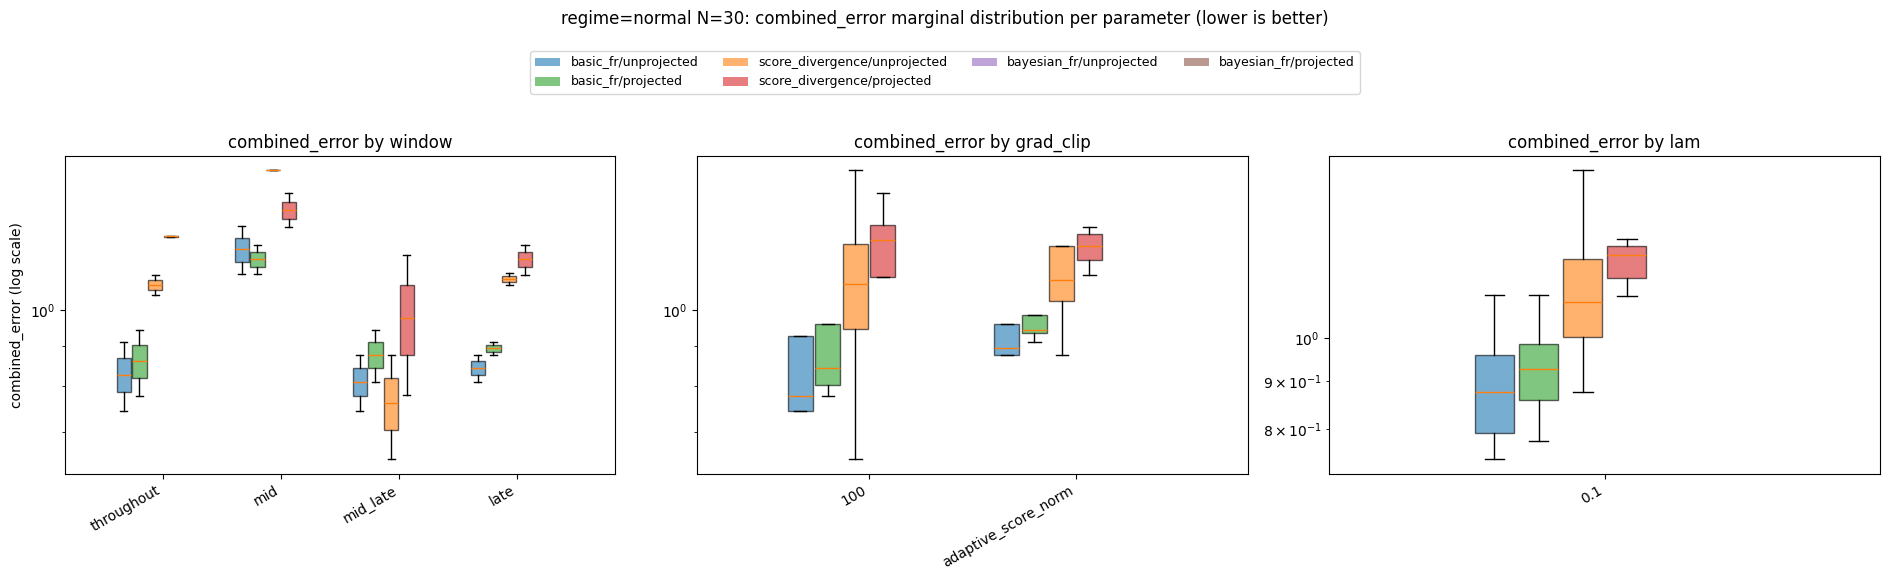

In [14]:
# Same (method, jacobian) -> color identity as the earlier diagnostic panel (blue/orange = unprojected,
# green/red = projected) so color means the same thing everywhere in this notebook.
GROUP_COLORS = {
    ("basic_fr", "unprojected"): "tab:blue",
    ("basic_fr", "projected"): "tab:green",
    ("score_divergence", "unprojected"): "tab:orange",
    ("score_divergence", "projected"): "tab:red",
    ("bayesian_fr", "unprojected"): "tab:purple",
    ("bayesian_fr", "projected"): "tab:brown",
}
GROUPS = list(GROUP_COLORS.keys())

def grouped_boxplot(ax, param_col, values):
    width = 0.8 / len(GROUPS)
    for gi, (method, jacobian) in enumerate(GROUPS):
        sub = guided[(guided.method == method) & (guided.jacobian == jacobian)]
        positions = [i + (gi - (len(GROUPS) - 1) / 2) * width for i in range(len(values))]
        box_data = [sub.loc[sub[param_col] == v, "combined_error"].values for v in values]
        bp = ax.boxplot(box_data, positions=positions, widths=width * 0.9, patch_artist=True, showfliers=False)
        for patch in bp["boxes"]:
            patch.set_facecolor(GROUP_COLORS[(method, jacobian)])
            patch.set_alpha(0.6)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(v) for v in values], rotation=30, ha="right")
    ax.set_yscale("log")
    ax.set_title(f"combined_error by {param_col}")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for ax, (param_col, values) in zip(axes, PARAM_COLS.items()):
    grouped_boxplot(ax, param_col, values)
axes[0].set_ylabel("combined_error (log scale)")

legend_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, alpha=0.6) for c in GROUP_COLORS.values()]
legend_labels = [f"{m}/{j}" for m, j in GROUPS]
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.08))
fig.suptitle(f"regime={REGIME} N={N}: combined_error marginal distribution per parameter (lower is better)", y=1.15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/param_marginals.png", dpi=120, bbox_inches="tight")
plt.show()

## Which methods stay close to the manifold *and* improve memorization

In [15]:
FIDELITY_MAX = baseline["fidelity_mse"]  * 1000000
MEM_MAX = baseline["mem_ratio"] 

qualifying = guided[(guided["fidelity_mse"] < FIDELITY_MAX) & (guided["mem_ratio"] < MEM_MAX)].sort_values("combined_error")
print(f"{len(qualifying)}/{len(guided)} configs satisfy fidelity_mse < {FIDELITY_MAX} and mem_ratio < {MEM_MAX}\n")

print("By method/jacobian, how many configs qualify (robustness of the win, not just best case):")
print(qualifying.groupby(["method", "jacobian"]).size().sort_values(ascending=False).to_string())

print("\nTop 10 qualifying configs:")
print(qualifying.head(10)[["method", "jacobian", "window", "grad_clip", "lam", "mem_ratio", "fidelity_mse", "combined_error"]].to_string(index=False))

15/32 configs satisfy fidelity_mse < 813.8160337693989 and mem_ratio < 0.15000000596046448

By method/jacobian, how many configs qualify (robustness of the win, not just best case):
method            jacobian   
basic_fr          projected      6
                  unprojected    6
score_divergence  unprojected    2
                  projected      1

Top 10 qualifying configs:
          method    jacobian     window           grad_clip  lam  mem_ratio  fidelity_mse  combined_error
score_divergence unprojected   mid_late                 100  0.1      0.095      0.000975        0.645308
        basic_fr unprojected throughout                 100  0.1      0.110      0.000846        0.743733
        basic_fr unprojected   mid_late                 100  0.1      0.110      0.000858        0.743871
        basic_fr   projected throughout                 100  0.1      0.115      0.000849        0.777095
score_divergence   projected   mid_late                 100  0.1      0.115      0.000925 

## Scatter view: unguided vs the two best qualifying configs

no qualifying config for: [('bayesian_fr', 'unprojected'), ('bayesian_fr', 'projected')]


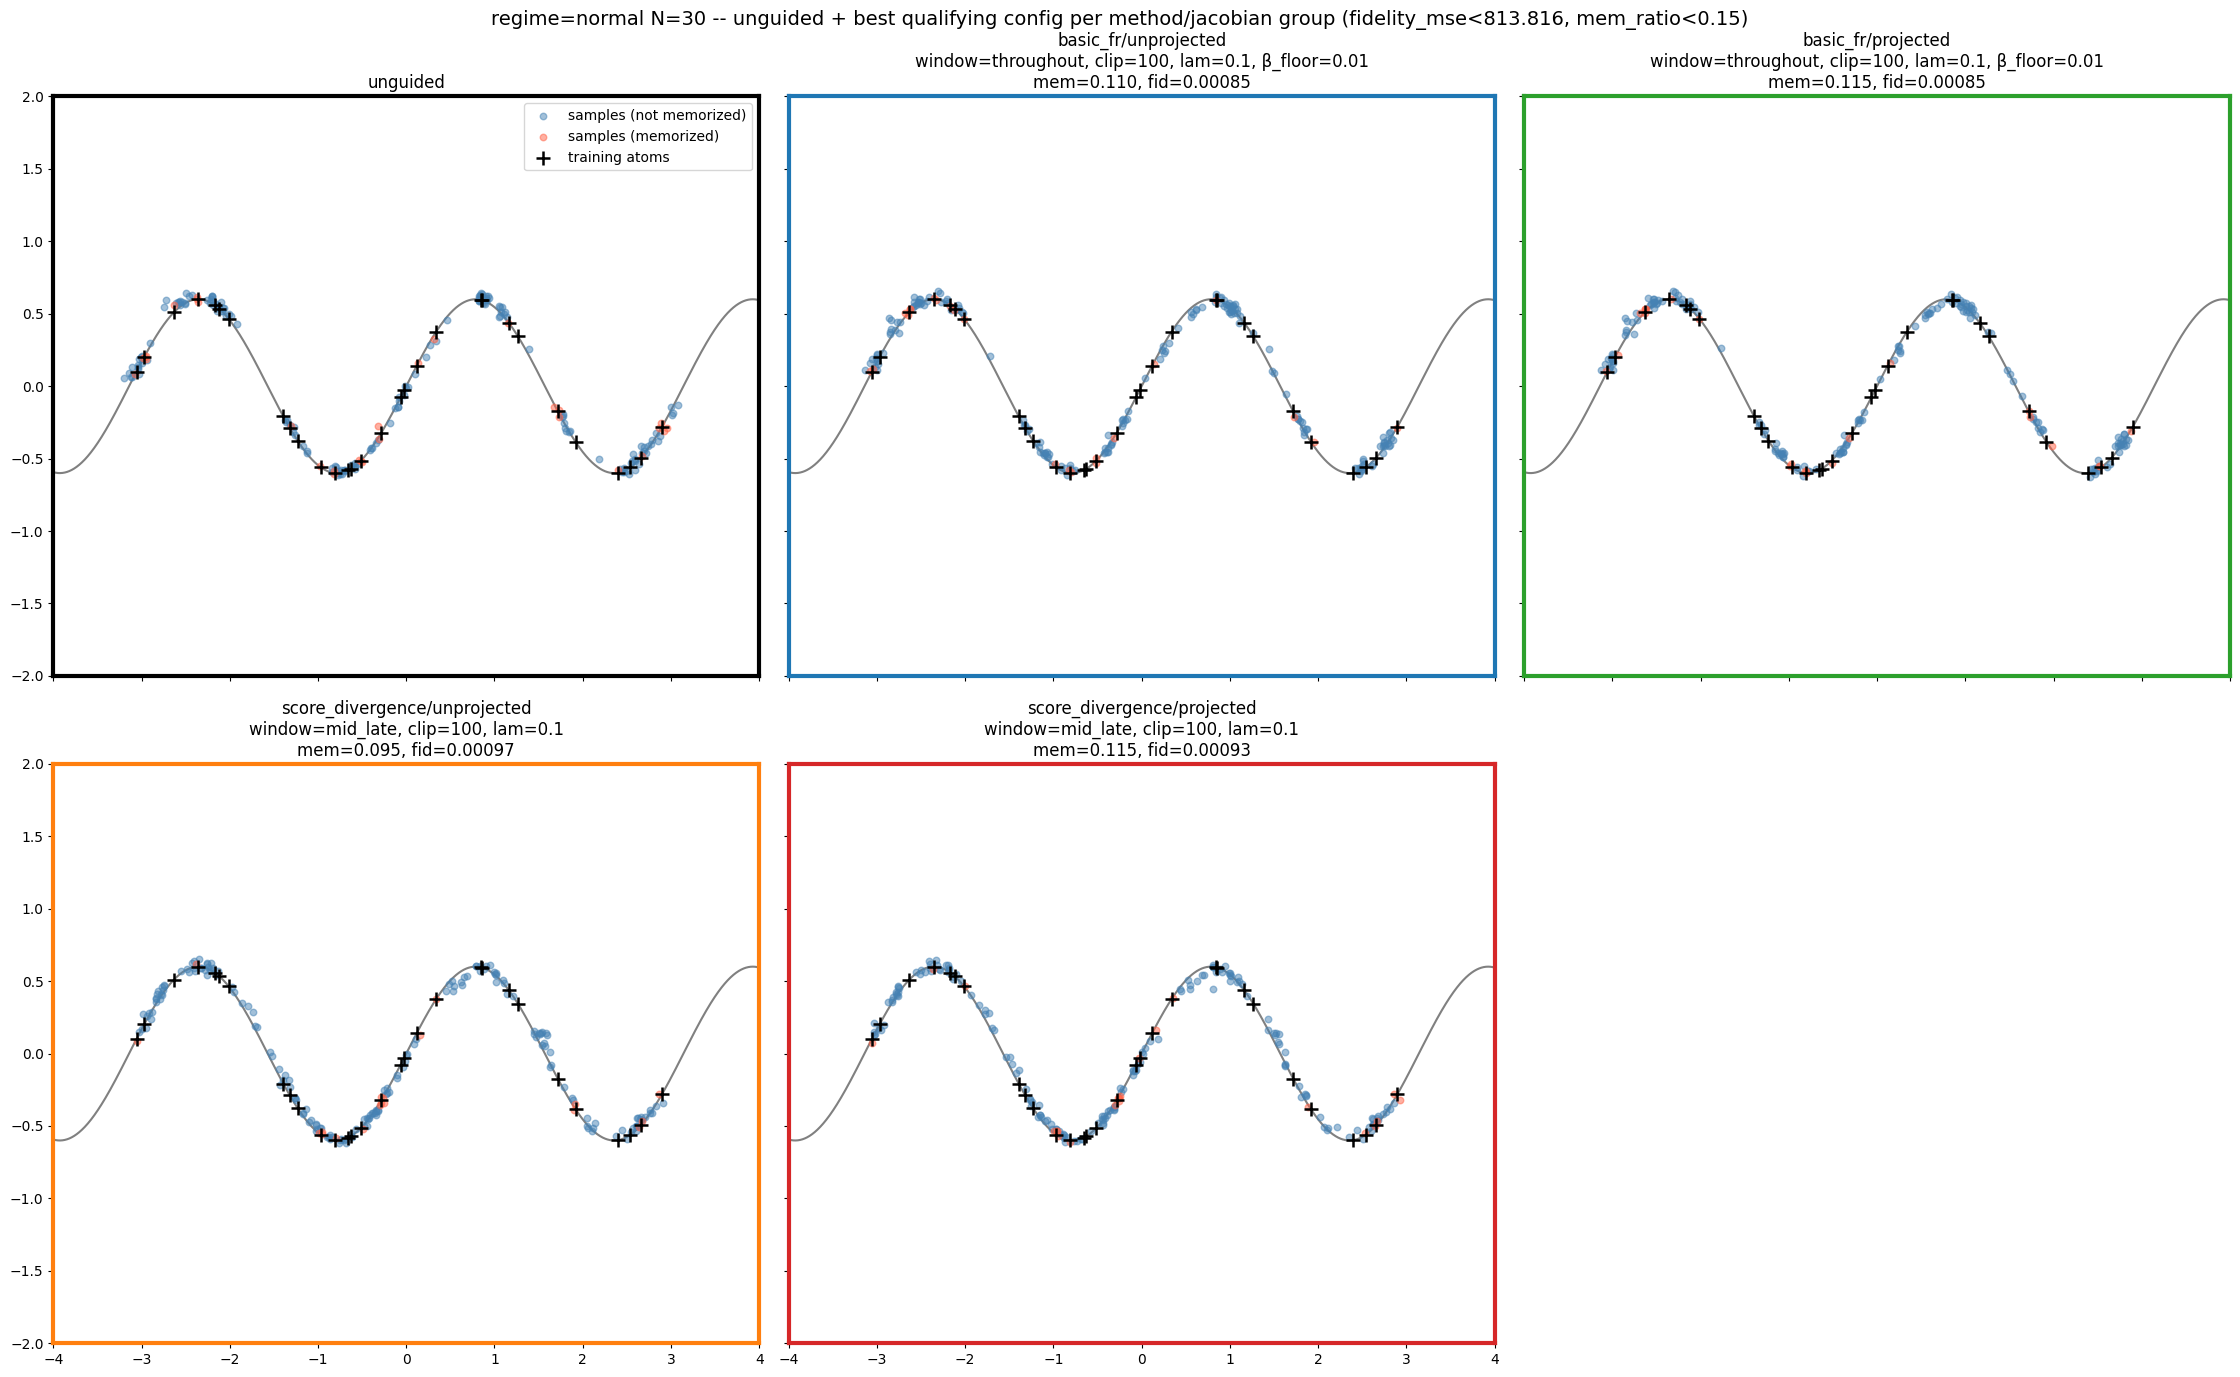

In [16]:
top2 = qualifying.head(2)   # kept for later cells (FR-energy-vs-memorization boxplot, score field surface)

# Best qualifying config per (method, jacobian) group 
best_per_group = {}
for method, jacobian in GROUPS:
    sub = qualifying[(qualifying.method == method) & (qualifying.jacobian == jacobian)]
    if len(sub):
        best_per_group[(method, jacobian)] = sub.sort_values("combined_error").iloc[0]
missing = [g for g in GROUPS if g not in best_per_group]
if missing:
    print(f"no qualifying config for: {missing}")

picks = [("unguided", "unprojected", "n/a", 0.0, 0.0, 0.0, 0.0)] + [
    (row["method"], row["jacobian"], row["window"], row["grad_clip"], row["lam"], row["bb_alpha"], row["beta_floor"])
    for row in best_per_group.values()
]

N_COLS = 3
n_rows = (len(picks) + N_COLS - 1) // N_COLS
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(7.5 * N_COLS, 7 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()
for ax, key in zip(axes, picks):
    X = samples_cache[key]
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="gray", lw=1.5, zorder=0)
    # color = memorized status (not just overlap density) -- same tomato/steelblue convention as the
    # "FR energy vs memorization" boxplot below, so color means the same thing across the notebook.
    # alpha still lets density show through within each group (more overlapping dots -> visibly denser).
    ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=22, color="steelblue", alpha=0.5,
               label="samples (not memorized)", zorder=1)
    ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=22, color="tomato", alpha=0.5,
               label="samples (memorized)", zorder=2)
    # A small "+" just pins the exact atom location -- no fill/area, so it can't be misread as a
    # memorization "zone" the way a big filled/outlined marker would (memorization is a RATIO to the
    # 2nd-nearest atom, not a distance threshold around any one atom, so no fixed-radius marker is
    # actually correct here -- see the classification check in conversation before this edit).
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=110, color="black",
               marker="+", linewidths=1.8, label="training atoms", zorder=5)
    method, jacobian, window, gc, lam, bb_alpha, beta_floor = key
    if method == "unguided":
        title = "unguided"
        spine_color = "black"
    else:
        row = qualifying[(qualifying.method == method) & (qualifying.jacobian == jacobian) &
                          (qualifying.window == window) & (qualifying.grad_clip == gc) &
                          (qualifying.lam == lam) & (qualifying.bb_alpha == bb_alpha) &
                          (qualifying.beta_floor == beta_floor)].iloc[0]
        title = (f"{method}/{jacobian}\nwindow={window}, clip={fmt_clip(gc)}, lam={lam:g}" +
                 (f", α={bb_alpha:g}" if method == "bayesian_fr" else "") +
                 (f", β_floor={beta_floor:g}" if method in ("basic_fr", "bayesian_fr") else "") +
                 f"\nmem={row.mem_ratio:.3f}, fid={row.fidelity_mse:.5f}")
        spine_color = GROUP_COLORS[(method, jacobian)]
    for spine in ax.spines.values():
        spine.set_edgecolor(spine_color); spine.set_linewidth(3)
    ax.set_title(title, fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(-2, 2)
for ax in axes[len(picks):]:
    ax.axis("off")
axes[0].legend(fontsize=10)
plt.suptitle(f"regime={REGIME} N={N} -- unguided + best qualifying config per method/jacobian group "
             f"(fidelity_mse<{np.round(FIDELITY_MAX, 4)}, mem_ratio<{np.round(MEM_MAX, 3)})", fontsize=14)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fr_comparison.png", dpi=120); plt.show()

## Effect of `beta_floor`: basic_fr, unprojected vs. projected, per beta_floor value

Isolates `beta_floor`'s effect specifically for `basic_fr` (the method it was introduced to fix): a grid with
rows = `unprojected`/`projected` and columns = each swept `beta_floor` value. Each panel is that
`(jacobian, beta_floor)` combination's OWN best qualifying config over the other hyperparameters
(window/grad_clip/lam) -- i.e. holding jacobian type fixed within a row and reading left-to-right shows
what changing beta_floor alone buys you, at each config's own best hyperparameter choice, rather than at one
hyperparameter choice held fixed across all of them.

IndexError: index 1 is out of bounds for axis 0 with size 1

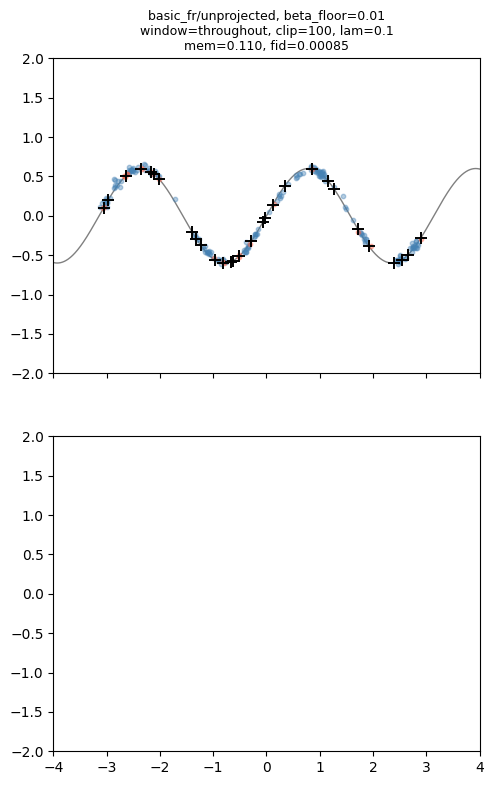

In [17]:
BASIC_FR_JACOBIANS = ["unprojected", "projected"]
basic_fr_beta_floors = config["beta_floors"]

best_per_bf = {}
for jacobian_name in BASIC_FR_JACOBIANS:
    for beta_floor in basic_fr_beta_floors:
        sub = qualifying[(qualifying.method == "basic_fr") & (qualifying.jacobian == jacobian_name) &
                          (qualifying.beta_floor == beta_floor)]
        if len(sub):
            best_per_bf[(jacobian_name, beta_floor)] = sub.sort_values("combined_error").iloc[0]
missing_bf = [(j, b) for j in BASIC_FR_JACOBIANS for b in basic_fr_beta_floors if (j, b) not in best_per_bf]
if missing_bf:
    print(f"no qualifying config for: {missing_bf}")

n_rows_bf, n_cols_bf = len(BASIC_FR_JACOBIANS), len(basic_fr_beta_floors)
fig, axes = plt.subplots(n_rows_bf, n_cols_bf, figsize=(5.5 * n_cols_bf, 4.5 * n_rows_bf), sharex=True, sharey=True)
axes = np.atleast_2d(axes)
for ri, jacobian_name in enumerate(BASIC_FR_JACOBIANS):
    for ci, beta_floor in enumerate(basic_fr_beta_floors):
        ax = axes[ri, ci]
        ax.plot(curve_scan[:, 0].cpu(), curve_scan[:, 1].cpu(), color="gray", lw=1, zorder=0)
        row = best_per_bf.get((jacobian_name, beta_floor))
        if row is None:
            ax.set_title(f"basic_fr/{jacobian_name}\nbeta_floor={beta_floor:g}\n(no qualifying config)", fontsize=9)
            ax.set_xlim(-4, 4); ax.set_ylim(-2, 2)
            continue
        key = ("basic_fr", jacobian_name, row["window"], row["grad_clip"], row["lam"], row["bb_alpha"], beta_floor)
        X = samples_cache[key]
        mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
        ax.scatter(X[~mem, 0].cpu(), X[~mem, 1].cpu(), s=10, color="steelblue", alpha=0.4,
                   label="samples (not memorized)", zorder=1)
        ax.scatter(X[mem, 0].cpu(), X[mem, 1].cpu(), s=10, color="tomato", alpha=0.4,
                   label="samples (memorized)", zorder=2)
        ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), s=70, color="black",
                   marker="+", linewidths=1.4, label="training atoms", zorder=5)
        title = (f"basic_fr/{jacobian_name}, beta_floor={beta_floor:g}\n"
                 f"window={row['window']}, clip={fmt_clip(row['grad_clip'])}, lam={row['lam']:g}\n"
                 f"mem={row.mem_ratio:.3f}, fid={row.fidelity_mse:.5f}")
        ax.set_title(title, fontsize=9)
        ax.set_xlim(-4, 4); ax.set_ylim(-2, 2)
axes[0, 0].legend(fontsize=8)
plt.suptitle(f"regime={REGIME} N={N} -- basic_fr: best qualifying config per (jacobian, beta_floor) "
             f"(unguided baseline: mem={baseline['mem_ratio']:.3f}, fid={baseline['fidelity_mse']:.5f})")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/basic_fr_beta_floor_comparison.png", dpi=120); plt.show()

## Fisher-Rao energy at the final point vs. memorization

Descriptive check: does the k-NN FR energy `I(y)` (evaluated at each sample's own final position, at the
temperature the sampler used in its last step) actually separate memorized from non-memorized samples? If FR
energy is a meaningful "closeness to a memorized mode" signal, memorized samples should sit at systematically
lower `I(y)` than non-memorized ones -- and guidance should be pushing samples away from the low-energy
(memorized) region.

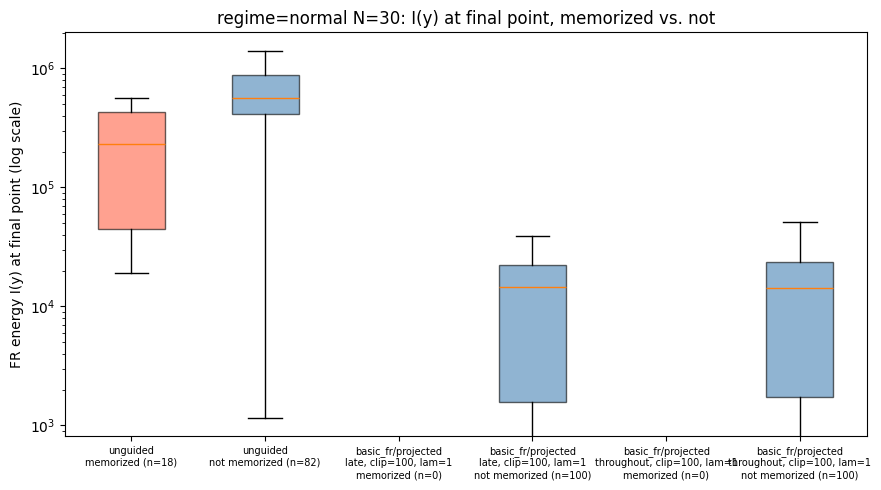

In [ ]:
_sigma2_final_scalar = sigma2(torch.tensor(dt)).item()

def energy_at_final_point(X):
    # I(y) at the sampler's final temperature (t=dt, the last step actually taken), independent
    # of whichever method/window/lam produced X -- a fixed yardstick for comparing conditions.
    # beta_floor=config["beta_floor"] (the fixed default, NOT whichever beta_floor guided this
    # particular X) is essential here: t=dt is the single most extreme dead-zone point in the
    # whole schedule (sigma_t^2 ~1e-4), so evaluating without it collapses I(y) to EXACTLY 0 for
    # every genuinely-memorized sample and to a mix of 0s and rare, wildly exploding outliers
    # (up to 1e7) for everything else -- verified directly: memorized/not-memorized both had
    # median 0 without the floor, an uninformative near-coin-flip, not a real signal.
    sigma2_final = torch.full((X.shape[0],), _sigma2_final_scalar)
    neighbors, _ = basic_fr.ann_query(index, X, config["k_neighbors"])
    I, _, _ = basic_fr.fisher_rao_energy(X, neighbors, sigma2_final, beta_floor=config["beta_floor"])
    return I

picks_energy = [("unguided", "unprojected", "n/a", 0.0, 0.0, 0.0, 0.0)] + [
    (r["method"], r["jacobian"], r["window"], r["grad_clip"], r["lam"], r["bb_alpha"], r["beta_floor"]) for _, r in top2.iterrows()
]

box_data, box_labels, box_colors = [], [], []
for key in picks_energy:
    X = samples_cache[key]
    mem = is_memorized(X, X_target, config["mem_ratio_threshold"])
    I = energy_at_final_point(X)
    label = "unguided" if key[0] == "unguided" else f"{key[0]}/{key[1]}\n{key[2]}, clip={fmt_clip(key[3])}, lam={key[4]:g}"
    box_data += [I[mem].numpy(), I[~mem].numpy()]
    box_labels += [f"{label}\nmemorized (n={int(mem.sum())})", f"{label}\nnot memorized (n={int((~mem).sum())})"]
    box_colors += ["tomato", "steelblue"]

fig, ax = plt.subplots(figsize=(3 * len(picks_energy), 5))
bp = ax.boxplot(box_data, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=7)
ax.set_yscale("log")   # I(y) still spans orders of magnitude even with beta_floor applied
                        # (the outer 1/sigma_t^2 scale is still huge this close to t=0)
ax.set_ylabel("FR energy I(y) at final point (log scale)")
ax.set_title(f"regime={REGIME} N={N}: I(y) at final point, memorized vs. not")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fr_energy_vs_memorization.png", dpi=120); plt.show()

## Full 2D score field: heatmaps + 3D surface


In [ ]:

def mixture_score(points, atoms, t):
    t_scalar = torch.tensor(t)
    a = alpha_bar(t_scalar)
    var = (1 - a).clamp(min=1e-6)
    means = atoms * a.sqrt()                                    # [N, 2]
    diff = points[:, None, :] - means[None, :, :]                # [B, N, 2]
    logw = -(diff ** 2).sum(-1) / (2 * var)                       # [B, N]
    w = torch.softmax(logw, dim=1)
    return (w[:, :, None] * (means[None, :, :] - points[:, None, :])).sum(1) / var

def learned_score(points, t):
    t_vec = torch.full((points.shape[0],), t, device=device)
    with torch.no_grad():
        eps_hat = net(points, t_vec)
    return -eps_hat / sigma2(t_vec)[:, None].sqrt()

def guided_score(points, t, guidance_fn, lam):
    # "new" score under guidance = score(points, t) + lam * grad_guidance(points, t) -- NOT multiplied
    # by g(t)/step_scale_fn, see this section's markdown for why. guidance_fn is one of make_guidance_fn's
    # closures (driver.guidance_grad / driver.projected_guidance_grad under the hood), treating `points`
    # as z_t exactly like learned_score already does -- so this is the real guidance mechanism, not a
    # reimplementation of it. Sets t_vec_holder["t"] since guidance_fn/y_fn/energy_fn all read it.
    t_vec_holder["t"] = torch.full((points.shape[0],), t, device=device)
    base = learned_score(points, t)
    grad, _, _ = guidance_fn(points)
    return base + lam * grad


guided score uses best qualifying config: method=basic_fr jacobian=projected grad_clip=100 lam=1


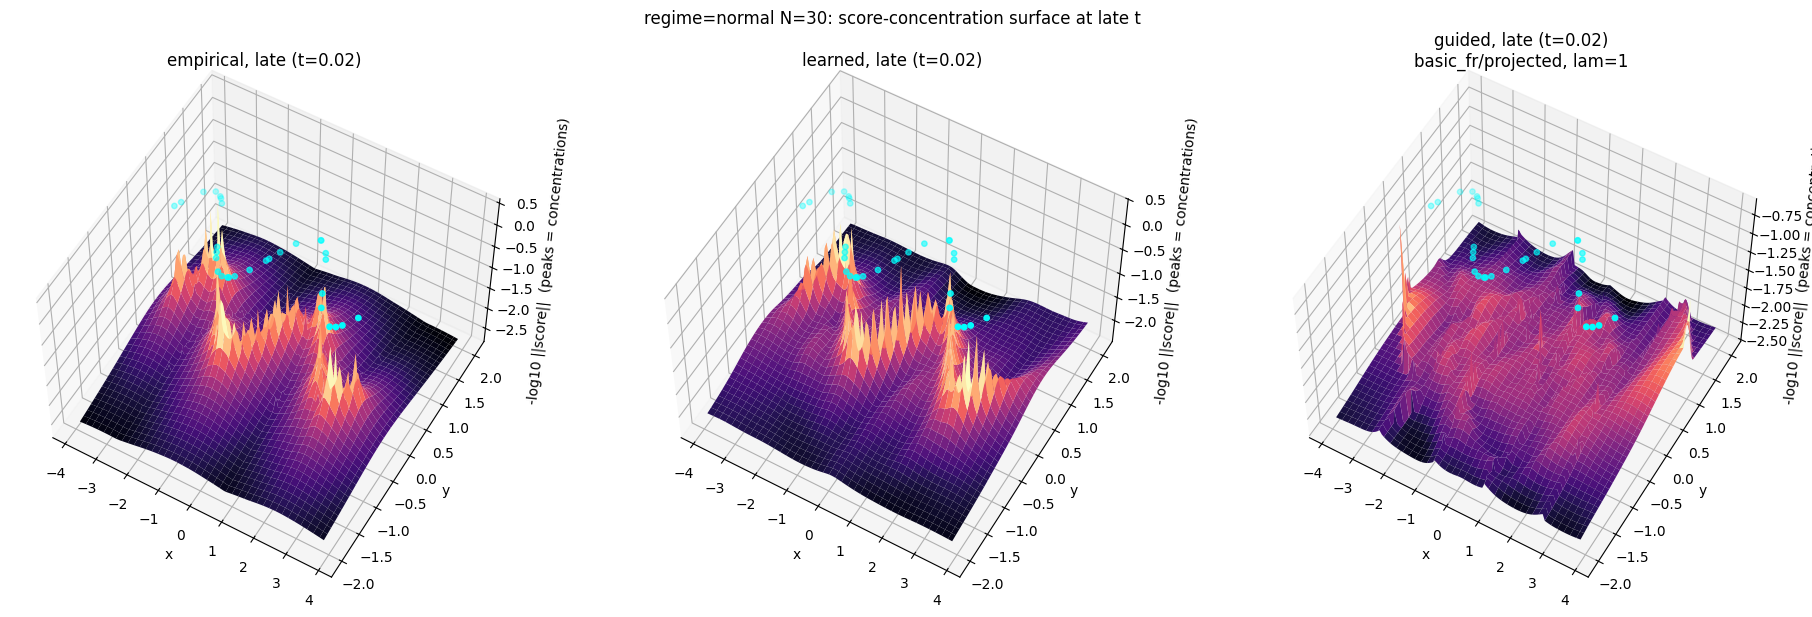

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

T_POINTS = {"early": 0.9, "mid": 0.3, "late": 0.02}   # early/mid/late = stage of the REVERSE (generation)
                                                       # process, matching `windows` above: early=noisy
                                                       # (high t), late=clean (low t) -- NOT forward-diffusion
                                                       # time. At high t the diffused mixture collapses onto
                                                       # a single Gaussian near the origin regardless of N or
                                                       # atom positions (sqrt(alpha_bar_t)*atom -> 0) -- that's
                                                       # the VP-SDE correctly converging to its N(0,I) prior,
                                                       # not a bug. Atom-level structure only survives at low t.
SLICE_N = 400


GRID_N = 120
SCORE_EPS = 1e-3
gx = torch.linspace(-1.2 * train_config["u_range"], 1.2 * train_config["u_range"], GRID_N)
gy = torch.linspace(-2.0, 2.0, GRID_N)
GX, GY = torch.meshgrid(gx, gy, indexing="xy")
grid_points = torch.stack([GX.reshape(-1), GY.reshape(-1)], dim=-1)

best_row = top2.iloc[0]
best_guidance_fn = make_guidance_fn(best_row["method"], best_row["jacobian"], best_row["grad_clip"],
                                     bb_alpha=best_row["bb_alpha"] or None, beta_floor=best_row["beta_floor"] or None)
best_lam = best_row["lam"]
print(f"guided score uses best qualifying config: method={best_row['method']} jacobian={best_row['jacobian']} "
      f"grad_clip={fmt_clip(best_row['grad_clip'])} lam={best_lam:g}"
      + (f" bb_alpha={best_row['bb_alpha']:g}" if best_row['method'] == "bayesian_fr" else ""))

grid_neg_log = {}   # (kind, t_name) -> -log10(||score||), [GRID_N, GRID_N] -- peaks = concentrations
for t_name, t_val in T_POINTS.items():
    emp = mixture_score(grid_points, X_target, t_val).norm(dim=-1).reshape(GRID_N, GRID_N)
    learn = learned_score(grid_points, t_val).norm(dim=-1).reshape(GRID_N, GRID_N)
    guided = guided_score(grid_points, t_val, best_guidance_fn, best_lam).norm(dim=-1).reshape(GRID_N, GRID_N)
    grid_neg_log[("empirical", t_name)] = -torch.log10(emp.clamp(min=SCORE_EPS))
    grid_neg_log[("learned", t_name)] = -torch.log10(learn.clamp(min=SCORE_EPS))
    grid_neg_log[("guided", t_name)] = -torch.log10(guided.clamp(min=SCORE_EPS))

fig = plt.figure(figsize=(19, 6))
for i, kind in enumerate(["empirical", "learned", "guided"]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    Z = grid_neg_log[(kind, "late")]
    ax.plot_surface(GX.numpy(), GY.numpy(), Z.numpy(), cmap="magma", linewidth=0, antialiased=True)
    ax.scatter(X_target[:, 0].cpu(), X_target[:, 1].cpu(), torch.full((N,), Z.max().item()), color="cyan", s=15)
    ax.view_init(elev=55, azim=-60)   # steeper, more top-down angle -- default (elev=30) makes tall,
                                       # narrow peaks read as a descending ramp instead of spikes
    title = f"{kind}, late (t={T_POINTS['late']})"
    if kind == "guided":
        title += f"\n{best_row['method']}/{best_row['jacobian']}, lam={best_lam:g}"
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("-log10 ||score||  (peaks = concentrations)")
fig.suptitle(f"regime={REGIME} N={N}: score-concentration surface at late t")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/score_field_surface_late.png", dpi=120, bbox_inches="tight")
plt.show()